# Evaluation

Evaluates the results from the models.

In [1]:
!pip install pyprojroot

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [89]:
from transformers import AutoTokenizer, AutoConfig
from transformers import AutoModelForSequenceClassification

import polars as pl
import seaborn as sns
import numpy as np

from ast import literal_eval
from scipy.special import softmax

In [20]:
twitter_sentiment = pl.read_parquet("drive/MyDrive/Data/test_reduced_twitter-roberta-sentiment.parquet")
twitter_sentiment = twitter_sentiment.with_columns(pl.col("label").replace(old="conversative", new="conservative").alias("label"))

In [43]:
batch_16_epochs_5_all_layers = pl.read_parquet("drive/MyDrive/Data/test_reduced_fine_tune_batch16_epochs5_all_layers.parquet")
batch_16_epochs_5_all_layers = batch_16_epochs_5_all_layers.with_columns([
    pl.col("label").replace(old="conversative", new="conservative").alias("label"),
    pl.col("prediction").replace(old="conversative", new="conservative").alias("prediction")
    ]).rename({"conversative": "conservative"})

In [45]:
batch_32_epochs_3_all_layers = pl.read_parquet("drive/MyDrive/Data/test_reduced_fine_tune_batch32_epochs3_train_all_layers.parquet")
batch_32_epochs_3_all_layers = batch_32_epochs_3_all_layers.with_columns([
    pl.col("label").replace(old="conversative", new="conservative").alias("label"),
    pl.col("prediction").replace(old="conversative", new="conservative").alias("prediction")
    ]).rename({"conversative": "conservative"})

In [46]:
batch_32_epochs_3_classifier_11_embed = pl.read_parquet("drive/MyDrive/Data/test_reduced_fine_tune_batch32_epochs3_train_classifier_11_embed.parquet")
batch_32_epochs_3_classifier_11_embed = batch_32_epochs_3_classifier_11_embed.with_columns([
    pl.col("label").replace(old="conversative", new="conservative").alias("label"),
    pl.col("prediction").replace(old="conversative", new="conservative").alias("prediction")
    ]).rename({"conversative": "conservative"})

In [47]:
batch_32_epochs_3_classifier_embed = pl.read_parquet("drive/MyDrive/Data/test_reduced_fine_tune_batch32_epochs3_train_classifier_embed.parquet")
batch_32_epochs_3_classifier_embed = batch_32_epochs_3_classifier_embed.with_columns([
    pl.col("label").replace(old="conversative", new="conservative").alias("label"),
    pl.col("prediction").replace(old="conversative", new="conservative").alias("prediction")
    ]).rename({"conversative": "conservative"})

In [48]:
batch_32_epochs_3_embed_attention_classifier = pl.read_parquet("drive/MyDrive/Data/test_reduced_fine_tune_batch32_epochs3_train_embed_attention_classifier.parquet")
batch_32_epochs_3_embed_attention_classifier = batch_32_epochs_3_embed_attention_classifier.with_columns([
    pl.col("label").replace(old="conversative", new="conservative").alias("label"),
    pl.col("prediction").replace(old="conversative", new="conservative").alias("prediction")
    ]).rename({"conversative": "conservative"})

In [49]:
batch_8_epochs_8_classifier_11_embed = pl.read_parquet("drive/MyDrive/Data/test_reduced_fine_tune_batch8_epochs8_train_classifier_11_embed.parquet")
batch_8_epochs_8_classifier_11_embed = batch_8_epochs_8_classifier_11_embed.with_columns([
    pl.col("label").replace(old="conversative", new="conservative").alias("label"),
    pl.col("prediction").replace(old="conversative", new="conservative").alias("prediction")
    ]).rename({"conversative": "conservative"})

In [51]:
baseline = pl.read_parquet("drive/MyDrive/Data/test_reduced_baseline.parquet")
baseline = baseline.with_columns([
    pl.col("label").replace(old="conversative", new="conservative").alias("label"),
    pl.col("prediction").replace(old="conversative", new="conservative").alias("prediction")
    ])

In [53]:
baseline.head()

index,id,subreddit,username,username_score,content,label,conservative,neutral,liberal,prediction
u32,str,str,str,f64,str,str,i32,i32,i32,str
11508213,"""d0oshg2""","""Fitness""","""Magahaka""",0.95,"""""Eat your regular meals that y…","""conservative""",0,1,0,"""neutral"""
8398748,"""caphney""","""gardening""","""louchar""",0.0,"""'I used to get baked and do th…","""neutral""",0,1,0,"""neutral"""
28204105,"""cwufxng""","""Fantasy""","""xolsiion""",0.0,"""""I've read both Riyira Chronic…","""neutral""",0,1,0,"""neutral"""
7887909,"""e22e4z8""","""movies""","""LivnLegndNeedsEggs""",-0.7,"""'I second this. It is so obno…","""liberal""",0,1,0,"""neutral"""
2411655,"""cjblu8y""","""movies""","""RandomJPG6""",0.0,"""'R \n18+ \nM \nWhatever reg…","""neutral""",0,1,0,"""neutral"""


Text(0.5, 0, 'Poster Username Signal Label')

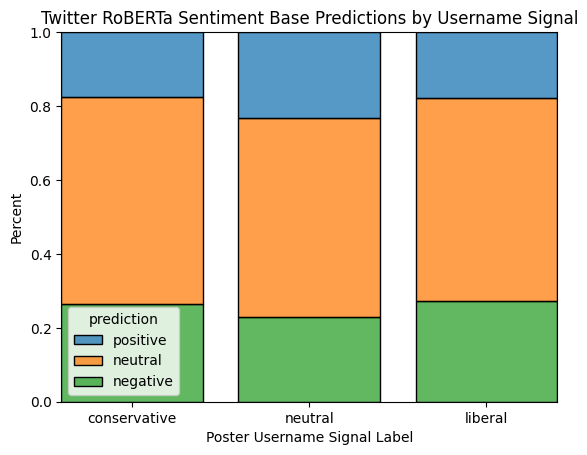

In [40]:
ax = sns.histplot(
    data=twitter_sentiment,
    x="label", hue="prediction",
    multiple="fill", stat="percent",
    discrete=True, shrink=.8
)
ax.set_title("Twitter RoBERTa Sentiment Base Predictions by Username Signal")
ax.set_xlabel("Poster Username Signal Label")

In [74]:
def get_cm(output):
  return output.group_by(["label", "prediction"]).agg(pl.len().alias("count"))

def get_tp(cm, class_name):
  try:
    return cm.filter((pl.col("label") == class_name) & (pl.col("prediction") == class_name)).get_column("count").item()
  except:
    return 0

def get_fp(cm, class_name):
  return cm.filter((pl.col("label") != class_name) & (pl.col("prediction") == class_name)).get_column("count").sum()

def get_fn(cm, class_name):
  return cm.filter((pl.col("label") == class_name) & (pl.col("prediction") != class_name)).get_column("count").sum()

def get_precision(cm, class_name):
  try:
    return get_tp(cm, class_name) / (get_tp(cm, class_name) + get_fp(cm, class_name))
  except:
    return 1 # Does not matter for f1, recall will be 0

def get_recall(cm, class_name):
    return get_tp(cm, class_name) / (get_tp(cm, class_name) + get_fn(cm, class_name))

def get_f1(cm, class_name):
  return get_tp(cm, class_name) / (get_tp(cm, class_name) + get_fn(cm, class_name))

def get_f1(cm, class_name):
  precision = get_precision(cm, class_name)
  recall = get_recall(cm, class_name)
  if precision + recall == 0:
    return 0
  return 2 * (precision * recall) / (precision + recall)

def get_macro_f1(cm):
  return (get_f1(cm, "conservative") + get_f1(cm, "liberal") + get_f1(cm, "neutral")) / 3

In [75]:
outputs = {
    "batch_16_epochs_5_all_layers": batch_16_epochs_5_all_layers,
    "batch_32_epochs_3_all_layers": batch_32_epochs_3_all_layers,
    "batch_32_epochs_3_classifier_11_embed": batch_32_epochs_3_classifier_11_embed,
    "batch_32_epochs_3_classifier_embed": batch_32_epochs_3_classifier_embed,
    "batch_32_epochs_3_embed_attention_classifier": batch_32_epochs_3_embed_attention_classifier,
    "batch_8_epochs_8_classifier_11_embed": batch_8_epochs_8_classifier_11_embed,
    "baseline": baseline
}

for name, output in outputs.items():
  cm = get_cm(output)
  f1 = get_macro_f1(cm)
  print(f"{name}: {f1}")

batch_16_epochs_5_all_layers: 0.4794123134311942
batch_32_epochs_3_all_layers: 0.478209582672991
batch_32_epochs_3_classifier_11_embed: 0.47278554905416953
batch_32_epochs_3_classifier_embed: 0.474150618985491
batch_32_epochs_3_embed_attention_classifier: 0.46543387696933136
batch_8_epochs_8_classifier_11_embed: 0.4741643650069735
baseline: 0.2222222222222222


In [78]:
best_cm = get_cm(batch_16_epochs_5_all_layers)

precision_liberal = get_precision(best_cm, "liberal")
recall_liberal = get_recall(best_cm, "liberal")
f1_liberal = get_f1(best_cm, "liberal")

precision_neutral = get_precision(best_cm, "neutral")
recall_neutral = get_recall(best_cm, "neutral")
f1_neutral = get_f1(best_cm, "neutral")

precision_conservative = get_precision(best_cm, "conservative")
recall_conservative = get_recall(best_cm, "conservative")
f1_conservative = get_f1(best_cm, "conservative")

print("Liberal")
print(f"Precision: {precision_liberal}")
print(f"Recall: {recall_liberal}")
print(f"F1: {f1_liberal}")
print()

print("Neutral")
print(f"Precision: {precision_neutral}")
print(f"Recall: {recall_neutral}")
print(f"F1: {f1_neutral}")
print()

print("Conservative")
print(f"Precision: {precision_conservative}")
print(f"Recall: {recall_conservative}")
print(f"F1: {f1_conservative}")

Liberal
Precision: 0.4559432288586635
Recall: 0.29215611974232664
F1: 0.35612009237875286

Neutral
Precision: 0.5851989162983031
Recall: 0.6616153474125424
F1: 0.6210653753026635

Conservative
Precision: 0.45245813074014046
Recall: 0.46997755331088664
F1: 0.4610514726121663


In [99]:
# Preprocess text (username and link placeholders)
def preprocess(text):
    new_text = []
    for t in text.split():
        t = '@user' if t.startswith('@') and len(t) > 1 else t
        t = 'http' if t.startswith('http') else t
        new_text.append(t)
    return " ".join(new_text)

# Setup model and tokenizer for best model
tokenizer = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")
best_config = AutoConfig.from_pretrained("drive/MyDrive/Data/fine_tune_batch16_epochs5_all_layers")
best_model = AutoModelForSequenceClassification.from_pretrained("drive/MyDrive/Data/fine_tune_batch16_epochs5_all_layers")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [134]:
experiment = pl.read_parquet("drive/MyDrive/Data/experiment.parquet")

In [151]:
experiment = experiment.with_columns(pl.col("label").replace(old="conversative", new="conservative").alias("label"))

In [152]:
experiment

id,subreddit,username,username_score,content,label
str,str,str,i64,str,str
"""booksuggestions""","""1rwn60r""","""Fresh_Window_6484""",0,"""""The Emperor's Assassin series…","""neutral"""
"""booksuggestions""","""1rwn60r""","""Fresh_Window_6484""",0,"""'You might like The Darktouche…","""neutral"""
"""AskMen""","""1rvbenb""","""Fresh_Window_6484""",0,"""'Your submission was removed b…","""neutral"""
"""socialskills""","""1rpex9a""","""Fresh_Window_6484""",0,"""'\nThanks for your post at /r/…","""neutral"""
"""socialskills""","""1rpex9a""","""Fresh_Window_6484""",0,"""'Be ok with having uncomfortab…","""neutral"""
…,…,…,…,…,…
"""camping""","""1s0bn9y""","""MAGA_victory24""",1,"""'If I am car camping I bring a…","""conservative"""
"""camping""","""1s0bn9y""","""MAGA_victory24""",1,"""'Burn a 12 hour candle inside …","""conservative"""
"""camping""","""1s0bn9y""","""MAGA_victory24""",1,"""'Tents vary a lot, so some of …","""conservative"""


In [137]:
def inference_single(content, model, labels) -> dict[str, np.float32]:
    text = preprocess(literal_eval(content))
    encoded_input = tokenizer(text, return_tensors='pt', truncation=True, max_length=512)
    output = model(**encoded_input)
    scores = softmax(output[0][0].detach().numpy())
    return {label: float(score) for label, score in zip(labels, scores)}

In [138]:
best_label_order = ["conservative", "liberal", "neutral"] # Wasn't saved with model
inference_single(experiment.head(10).row(2, named=True)["content"], best_model, best_label_order)

{'conservative': 0.49490851163864136,
 'liberal': 0.10796821117401123,
 'neutral': 0.3971233069896698}

In [139]:
experiment_best_model = experiment.with_columns(
    pl.col("content")
    .map_elements(lambda x: inference_single(x, best_model, best_label_order),
                  return_dtype=pl.Struct({label: pl.Float64 for label in best_label_order}),)
    .alias("score")
).unnest("score")

In [140]:
experiment_best_model = experiment_best_model.with_columns(
    pl.when(pl.col("liberal") > pl.col("neutral")).then(
        pl.when(pl.col("liberal") > pl.col("conservative"))
        .then(pl.lit("liberal"))
        .otherwise(pl.lit("conservative"))
    ).otherwise(pl.when(pl.col("neutral") > pl.col("conservative"))
        .then(pl.lit("neutral"))
        .otherwise(pl.lit("conservative"))
    ).alias("prediction"))

In [154]:
experiment_best_model.write_parquet("drive/MyDrive/Data/experiment_best_model.parquet")

In [142]:
# Setup model and tokenizer for original sentiment classifier
base_config = AutoConfig.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")
base_model = AutoModelForSequenceClassification.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [143]:
experiment_base_sentiment = experiment.with_columns(
    pl.col("content")
    .map_elements(lambda x: inference_single(x, base_model, base_config.id2label.values()),
                  return_dtype=pl.Struct({'negative': pl.Float64, 'neutral': pl.Float64, 'positive': pl.Float64}))
    .alias("score")
).unnest("score")

In [144]:
experiment_base_sentiment = experiment_base_sentiment.with_columns(
    pl.when(pl.col("negative") > pl.col("neutral")).then(
        pl.when(pl.col("negative") > pl.col("positive"))
        .then(pl.lit("negative"))
        .otherwise(pl.lit("positive"))
    ).otherwise(pl.when(pl.col("neutral") > pl.col("positive"))
        .then(pl.lit("neutral"))
        .otherwise(pl.lit("positive"))
    ).alias("prediction"))

In [156]:
experiment_base_sentiment.write_parquet("drive/MyDrive/Data/experiment_base_sentiment.parquet")

In [162]:
experiment_baseline = experiment.with_columns([
    pl.lit("neutral").alias("prediction")
])

Text(0.5, 0, 'Experiment Condition')

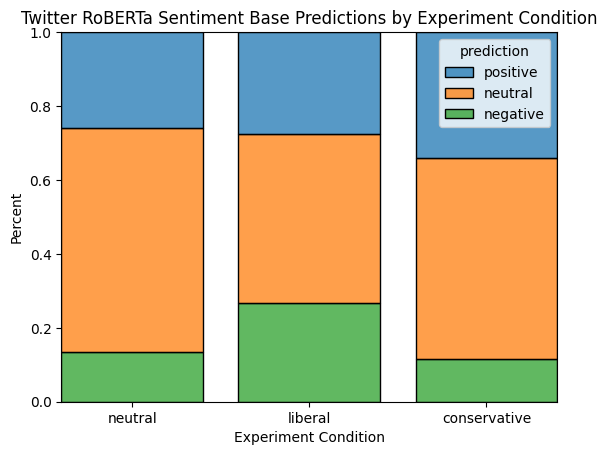

In [157]:
ax = sns.histplot(
    data=experiment_base_sentiment,
    x="label", hue="prediction",
    hue_order=["positive", "neutral", "negative"],
    multiple="fill", stat="percent",
    discrete=True, shrink=.8
)
ax.set_title("Twitter RoBERTa Sentiment Base Predictions by Experiment Condition")
ax.set_xlabel("Experiment Condition")

In [161]:
# Metrics for the best model on the experiment

experiment_cm = get_cm(experiment_best_model)

precision_liberal = get_precision(experiment_cm, "liberal")
recall_liberal = get_recall(experiment_cm, "liberal")
f1_liberal = get_f1(experiment_cm, "liberal")

precision_neutral = get_precision(experiment_cm, "neutral")
recall_neutral = get_recall(experiment_cm, "neutral")
f1_neutral = get_f1(experiment_cm, "neutral")

precision_conservative = get_precision(experiment_cm, "conservative")
recall_conservative = get_recall(experiment_cm, "conservative")
f1_conservative = get_f1(experiment_cm, "conservative")

print("Liberal")
print(f"Precision: {precision_liberal}")
print(f"Recall: {recall_liberal}")
print(f"F1: {f1_liberal}")
print()

print("Neutral")
print(f"Precision: {precision_neutral}")
print(f"Recall: {recall_neutral}")
print(f"F1: {f1_neutral}")
print()

print("Conservative")
print(f"Precision: {precision_conservative}")
print(f"Recall: {recall_conservative}")
print(f"F1: {f1_conservative}")
print()

print(f"Macro F1: {get_macro_f1(experiment_cm)}")

Liberal
Precision: 0.30670926517571884
Recall: 0.09927611168562564
F1: 0.14999999999999997

Neutral
Precision: 0.35425467712733855
Recall: 0.643640350877193
F1: 0.4569871545348384

Conservative
Precision: 0.2526178010471204
Recall: 0.22573099415204678
F1: 0.2384187770228536

Macro F1: 0.28180197718589733


In [163]:
# Metrics for the baseline on the experiment

baseline_cm = get_cm(experiment_baseline)

precision_liberal = get_precision(baseline_cm, "liberal")
recall_liberal = get_recall(baseline_cm, "liberal")
f1_liberal = get_f1(baseline_cm, "liberal")

precision_neutral = get_precision(baseline_cm, "neutral")
recall_neutral = get_recall(baseline_cm, "neutral")
f1_neutral = get_f1(baseline_cm, "neutral")

precision_conservative = get_precision(baseline_cm, "conservative")
recall_conservative = get_recall(baseline_cm, "conservative")
f1_conservative = get_f1(baseline_cm, "conservative")

print("Liberal")
print(f"Precision: {precision_liberal}")
print(f"Recall: {recall_liberal}")
print(f"F1: {f1_liberal}")
print()

print("Neutral")
print(f"Precision: {precision_neutral}")
print(f"Recall: {recall_neutral}")
print(f"F1: {f1_neutral}")
print()

print("Conservative")
print(f"Precision: {precision_conservative}")
print(f"Recall: {recall_conservative}")
print(f"F1: {f1_conservative}")
print()

print(f"Macro F1: {get_macro_f1(experiment_cm)}")

Liberal
Precision: 1
Recall: 0.0
F1: 0.0

Neutral
Precision: 0.3335771762984638
Recall: 1.0
F1: 0.5002742731760833

Conservative
Precision: 1
Recall: 0.0
F1: 0.0

Macro F1: 0.28180197718589733


In [169]:
experiment_base_sentiment.sort(pl.col("negative"), descending=True).head()["content"].to_list()

["'I get irrationally angry when the hear the word “kiddo”. Even typing it out made me mad. It makes my skin crawl.'",
 "'Everything is so ass on netflix i just have to rewatch stuff now'",
 "'Buying cheap assemble it yourself furniture. Not only was is more expensive than the second hand furniture I have now it was so low quality and stuff would frequently break ans it looks awful.'",
 '"One of the more boring places i\'ve ever been"',
 '"I don\'t like Trader Joes at all. There\'s nothing there for me. :("']